# Solution for tutorial 2
***

In [1]:
#Importing packages
import pandas as pd
import numpy as np
from ISLP import load_data
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Task 1
***

### a)
***

In [2]:
#Data for regression
x = np.array([1, 2, 3, 4, 5, 6, 7], dtype = float)
y = np.array([0, 0, 1, 0, 1, 1, 1], dtype = float)

In [3]:
#Add constant for GLM
X = sm.add_constant(x)

In [4]:
#Fit model
m1 = sm.GLM(y, X, family = sm.families.Binomial()).fit()
print(m1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                    7
Model:                            GLM   Df Residuals:                        5
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2.4912
Date:                Sat, 16 May 2026   Deviance:                       4.9823
Time:                        16:08:17   Pearson chi2:                     4.14
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4801
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3614      3.330     -1.310      0.1

In [5]:
#Predicting Y for x0 = 4
a0 = m1.params[0]
a1 = m1.params[1]

prob = 1 / (1 + np.exp(-a0 - a1 * 4))

if prob >= 0.5:
    print(f"{prob:.4f} is above 0.5, classifying Y = 1")

else:
    print(f"{prob} is less than 0.5, classifying Y = 0")

0.6550 is above 0.5, classifying Y = 1


### b)
***

In [6]:
#Predicted probabilities
prob = m1.predict(X) #Does Sigmoid calculation automatically

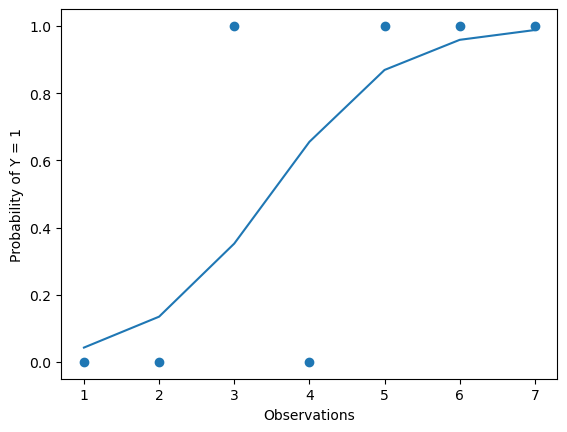

In [7]:
#Plot
plt.scatter(x, y)
plt.plot(x, prob)
plt.xlabel('Observations')
plt.ylabel('Probability of Y = 1')
plt.show()

### c)
***

In [8]:
#KNN
def knn(x0, x, y, K = 20):
    d = np.abs(x - x0) #Absolute difference between x0 and x
    o = np.argsort(d)[:K] #Sort up to K differences by indices
    yprob = np.mean(y[o]) #Mean of Y values of K neighbors

    return yprob

In [9]:
#Run KNN with K = 1, 3 and 5
for k in [1, 3, 5]:
    result = knn(4, x, y, K = k)
    print(f"Probability of Y = 1 for x0 = 4 with K = {k} is {result:.4f}")

Probability of Y = 1 for x0 = 4 with K = 1 is 0.0000
Probability of Y = 1 for x0 = 4 with K = 3 is 0.6667
Probability of Y = 1 for x0 = 4 with K = 5 is 0.6000


#### Interpretation

 - Row 1: Calculates absolute difference between $x_0$ and x for all values
 - Row 2: Sorts up to K differences in array d by indices
 - Row 3: Calculates mean for Y values of K neighbors to get probability of Y

### d)
***

In [10]:
#Calculating prob for KNN
prob_knn = []

for x_i in x:
    result = knn(x_i, x, y, K = 3)
    prob_knn.append(result)

prob_knn = np.array(prob_knn)

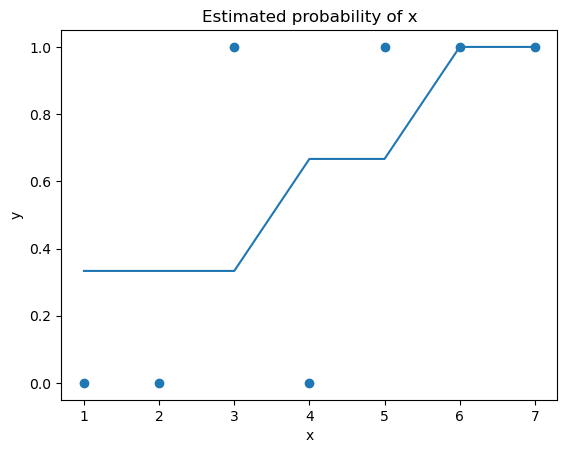

In [11]:
#Plot
plt.scatter(x, y)
plt.plot(x, prob_knn)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Estimated probability of x')
plt.show()

### e)
***

In [12]:
#Categorize as 1 and 0 based on 0.5 threshold
pred_lr = (prob > 0.5).astype(int)
pred_knn = (prob_knn > 0.5).astype(int)

In [13]:
#Forelesers metode for GLM
cm_glm = pd.crosstab(y, pred_lr)

accuracy_glm = (pred_lr == y).mean()
print(f"Share of accurate predictions: {accuracy_glm:.4f}")

cm_glm

Share of accurate predictions: 0.7143


col_0,0,1
row_0,,
0.0,2,1
1.0,1,3


In [14]:
#CM for KNN
cm_knn = pd.crosstab(y, pred_knn)

accuracy_knn = (pred_knn == y).mean()
print(f"Share of accurate predictions: {accuracy_knn:.4f}")

cm_knn

Share of accurate predictions: 0.7143


col_0,0,1
row_0,,
0.0,2,1
1.0,1,3


## Task 4
***

### a)
***

In [15]:
#Loading dataset
auto = load_data('Auto')
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


In [16]:
#Y variable for mpg above and below median
auto['y'] = np.where(auto['mpg'] > auto['mpg'].median(), 'high', 'low')
auto['y'] = auto['y'].astype('category')

#Create 'age' variable
auto['age'] = 83 - auto['year']

#Drop columns 'mpg', 'name' and 'year
auto = auto.drop(columns = ['mpg', 'year'])

auto.head()

,cylinders,displacement,horsepower,weight,acceleration,origin,y,age
name,,,,,,,,
chevrolet chevelle malibu,8,307.0,130,3504,12.0,1,low,13
buick skylark 320,8,350.0,165,3693,11.5,1,low,13
plymouth satellite,8,318.0,150,3436,11.0,1,low,13
amc rebel sst,8,304.0,150,3433,12.0,1,low,13
ford torino,8,302.0,140,3449,10.5,1,low,13


### b)
***

In [31]:
#Split data 50/50
np.random.seed(1234)
n = len(auto)

train_idx = np.random.choice(n, size = n // 2, replace = False)

train = auto.iloc[train_idx]
test = auto.iloc[~train_idx]

In [32]:
#Split into X and y
y_train = (train['y'] == 'high').astype(int)
X_train = sm.add_constant(train.drop(columns = 'y'))

In [49]:
#Logistic regression
logreg = sm.GLM(y_train, X_train, family = sm.families.Binomial()).fit()
print(logreg.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  196
Model:                            GLM   Df Residuals:                      188
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -38.254
Date:                Sat, 16 May 2026   Deviance:                       76.508
Time:                        16:36:45   Pearson chi2:                     87.0
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6305
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           19.3594      5.391      3.591   

### c)
***

In [52]:
#Selecting significant variables weight and age
X_train_new = sm.add_constant(train[['age', 'weight']])
X_test_new = sm.add_constant(test[['age', 'weight']])

In [58]:
#Logistic regression
logreg2 = sm.GLM(y_train, X_train_new, family = sm.families.Binomial()).fit()
print(logreg2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  196
Model:                            GLM   Df Residuals:                      193
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -41.398
Date:                Sat, 16 May 2026   Deviance:                       82.797
Time:                        16:43:32   Pearson chi2:                     90.4
No. Iterations:                     7   Pseudo R-squ. (CS):             0.6184
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.5152      2.986      6.200      0.0

In [68]:
#Testing
prob = logreg2.predict(X_test_new)

#Convert to 0/1
pred = (prob > 0.5).astype(int)

#Accuracy
y_test = (test['y'] == 'high').astype(int)
accuracy = (y_test == pred).mean()

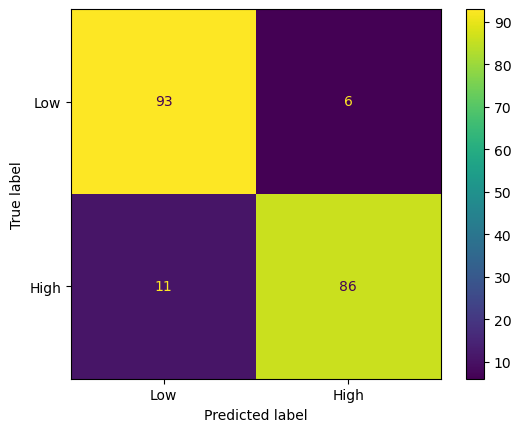

Share of accurate predictions: 0.9133


In [73]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Low', 'High'])
disp.plot()
plt.show()

print(f"Share of accurate predictions: {accuracy:.4f}")

In [85]:
#Forelesers metode
cm2 = pd.crosstab(y_test.values, pred.values, rownames = ['Actual'], colnames = ['Predicted'])
print(cm2)

Predicted   0   1
Actual           
0          93   6
1          11  86


### d)
***

In [ ]:
pred = np.zeros(n, dtype = int)

for i in range(n):
    train = auto[np.arange(n) != i] #All rows but i
    test = auto.iloc[[i]] #Row i

    y_train = (train['y'] == 'high').astype(int)
    X_train = sm.add_constant(train[['age', 'weight']])

    X_test = test[['age', 'weight']]
    X_test = X_test.reindex(columns = X_train.columns, fill_value = 1)

    m1 = sm.GLM(y_train, X_train, family = sm.families.Binomial()).fit()
    prob = m1.predict(X_test)
    pred[i] = (prob.iloc[0] > 0.5).astype(int)

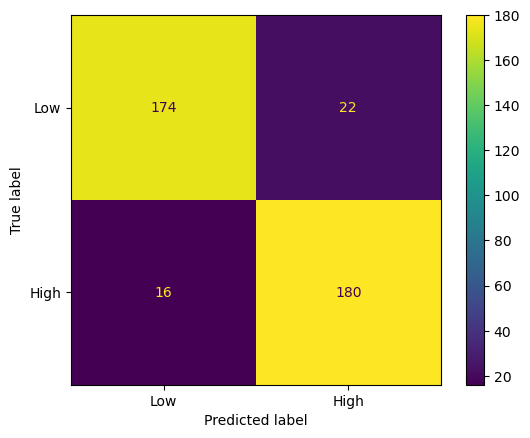

Share of accurate predictions: 0.9031


In [92]:
#Confusion matrix
y_test2 = (auto['y'] == 'high').astype(int)

cm2 = confusion_matrix(y_test2, pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm2, display_labels = ['Low', 'High'])
disp.plot()
plt.show()

#Accuracy
accuracy2 = (y_test2 == pred).mean()
print(f"Share of accurate predictions: {accuracy2:.4f}")

In [96]:
#Forelesers metode for CM
cm_foreleser = pd.crosstab(y_test2, pred, rownames = ['Actual'], colnames = ['Predicted'])
print(cm_foreleser)

Predicted    0    1
Actual             
0          174   22
1           16  180
